<a href="https://colab.research.google.com/github/KBhavithKumar/MachineLearningLab/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## K Means Clustering

In [22]:
# 1. Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [37]:
# 2. Import the train and test datasets

train = pd.read_csv("mnist_train.csv")
test = pd.read_csv("mnist_test.csv")

In [24]:
train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,1x11,1x12,1x13,1x14,1x15,1x16,1x17,1x18,1x19,1x20,1x21,1x22,1x23,1x24,1x25,1x26,1x27,1x28,2x1,2x2,2x3,2x4,2x5,2x6,2x7,2x8,2x9,2x10,2x11,...,27x17,27x18,27x19,27x20,27x21,27x22,27x23,27x24,27x25,27x26,27x27,27x28,28x1,28x2,28x3,28x4,28x5,28x6,28x7,28x8,28x9,28x10,28x11,28x12,28x13,28x14,28x15,28x16,28x17,28x18,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,147.0,252.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
test.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,1x11,1x12,1x13,1x14,1x15,1x16,1x17,1x18,1x19,1x20,1x21,1x22,1x23,1x24,1x25,1x26,1x27,1x28,2x1,2x2,2x3,2x4,2x5,2x6,2x7,2x8,2x9,2x10,2x11,...,27x17,27x18,27x19,27x20,27x21,27x22,27x23,27x24,27x25,27x26,27x27,27x28,28x1,28x2,28x3,28x4,28x5,28x6,28x7,28x8,28x9,28x10,28x11,28x12,28x13,28x14,28x15,28x16,28x17,28x18,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
# 3. Check shape of the data

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (10320, 785)
Test shape: (10000, 785)


In [39]:
# 4. Select only 10% of training data
# (KNN is slow on large datasets)

train_small = train.sample(frac=0.10, random_state=42)

In [41]:
# 5. Print shape of selected dataset

print("Selected dataset shape:", train_small.shape)

Selected dataset shape: (1032, 785)


In [42]:
# 6. Look at the top 5 rows
print(train_small.head())

      label  1x1  1x2  1x3  1x4  1x5  ...  28x23  28x24  28x25  28x26  28x27  28x28
2595      9    0    0    0    0    0  ...    0.0    0.0    0.0    0.0    0.0    0.0
3984      4    0    0    0    0    0  ...    0.0    0.0    0.0    0.0    0.0    0.0
6137      0    0    0    0    0    0  ...    0.0    0.0    0.0    0.0    0.0    0.0
6479      9    0    0    0    0    0  ...    0.0    0.0    0.0    0.0    0.0    0.0
39        6    0    0    0    0    0  ...    0.0    0.0    0.0    0.0    0.0    0.0

[5 rows x 785 columns]


In [44]:
# 7. Find number of unique class labels
print("Number of unique labels:", train_small['label'].nunique())

Number of unique labels: 10


In [46]:
# 8. Print number of examples per class

print("Examples per class:")
print(train_small['label'].value_counts())

Examples per class:
label
7    123
1    112
9    111
4    110
0    106
6    102
3    100
8     96
5     91
2     81
Name: count, dtype: int64


In [48]:
# 9. Prepare X and Y
X = train_small.drop("label", axis=1)
Y = train_small["label"]


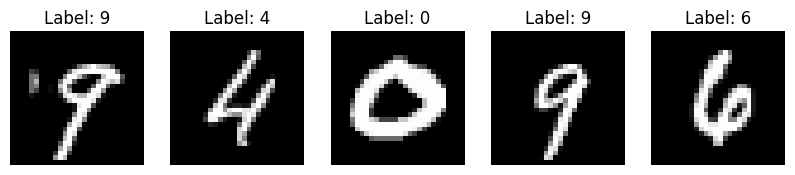

In [64]:
# 10. Visualize first 5 digits in X
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)

    image = X.iloc[i].values.reshape(28,28)
    plt.imshow(image, cmap="gray")

    plt.title("Label: "+str(Y.iloc[i]))
    plt.axis("off")

plt.show()

In [50]:

 # 11. Split dataset into train (75%)
# and validation (25%)

X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.25, random_state=42
)

In [52]:
# 12. Fit KNN classifier

knn = KNeighborsClassifier()

In [53]:
# 13. Default parameters
# n_neighbors=5
# metric='minkowski'
# p=2 (Euclidean distance)


knn.fit(X_train, y_train)

KNeighborsClassifier()

In [55]:
# 14. Predict validation set

y_pred = knn.predict(X_val)



In [57]:
# 15. Print confusion matrix

cm = confusion_matrix(y_val, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[30  0  0  0  0  0  0  0  0  0]
 [ 0 29  0  0  0  0  0  0  0  0]
 [ 3  4 15  0  0  1  0  1  0  0]
 [ 0  2  0 12  0  1  0  2  0  0]
 [ 0  0  0  0 18  0  0  0  0  6]
 [ 0  0  0  1  0 19  0  0  0  1]
 [ 0  0  0  0  0  1 26  0  0  0]
 [ 0  2  0  0  1  0  0 21  0  2]
 [ 0  6  0  2  1  1  1  1 18  1]
 [ 1  0  0  1  3  0  0  1  0 23]]


In [58]:
# 16. Print classification report
# and accuracy
# -------------------------------------
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        30
           1       0.67      1.00      0.81        29
           2       1.00      0.62      0.77        24
           3       0.75      0.71      0.73        17
           4       0.78      0.75      0.77        24
           5       0.83      0.90      0.86        21
           6       0.96      0.96      0.96        27
           7       0.81      0.81      0.81        26
           8       1.00      0.58      0.73        31
           9       0.70      0.79      0.74        29

    accuracy                           0.82       258
   macro avg       0.84      0.81      0.81       258
weighted avg       0.84      0.82      0.81       258

Validation Accuracy: 0.8178294573643411


In [59]:
# Prepare Kaggle test dataset
# -------------------------------------
X_test = test.drop("label", axis=1)
y_test = test["label"]

In [61]:
# Predict test dataset
# -------------------------------------
test_pred = knn.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, test_pred))


Test Accuracy: 0.8478


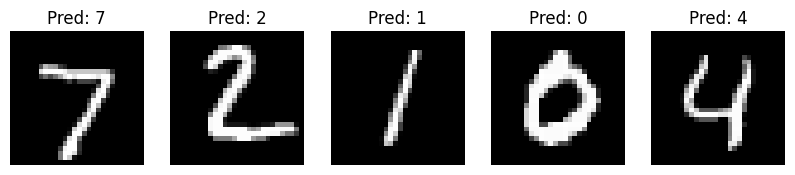

In [62]:
# 17. Visualize first 5 digits
# from test dataset and predicted label
# -------------------------------------
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)

    image = X_test.iloc[i].values.reshape(28,28)
    plt.imshow(image, cmap="gray")

    plt.title("Pred: "+str(test_pred[i]))
    plt.axis("off")

plt.show()